In [22]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv('/content/Cleaned spreadsheet_new.csv')

In [24]:
df.head()

,Date,Stock_name,Open,High,Low,Close,Adj_Close,Volume
0,2021-07-20,AAPL,143.46,147.10,142.96,146.15,142.45998,96350000
1,2021-07-20,MSFT,278.03,280.97,276.26,279.32,268.06250,26259700
2,2021-07-20,SPY,425.68,432.42,424.83,431.06,402.88200,99608200
3,2021-07-21,AAPL,145.53,146.13,144.63,145.40,141.72893,74993504
4,2021-07-21,MSFT,278.90,281.52,277.29,281.40,270.05860,24364300


In [25]:
df.shape

(3762, 8)

In [26]:
df.columns

Index(['Date', 'Stock_name', 'Open', 'High', 'Low', 'Close', 'Adj_Close',
       'Volume'],
      dtype='object')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        3762 non-null   object 
 1   Stock_name  3762 non-null   object 
 2   Open        3762 non-null   float64
 3   High        3762 non-null   float64
 4   Low         3762 non-null   float64
 5   Close       3762 non-null   float64
 6   Adj_Close   3762 non-null   float64
 7   Volume      3762 non-null   int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 235.3+ KB


In [28]:
df.describe()

,Open,High,Low,Close,Adj_Close,Volume
count,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3.762000e+03
mean,360.213923,363.045117,357.300152,360.325157,352.686289,5.565065e+07
std,154.380338,154.712264,153.813581,154.329627,152.039476,3.229931e+07
min,126.010000,127.770000,124.170000,125.020000,122.933556,5.855900e+06
25%,228.022500,230.410000,225.787500,228.022500,225.921372,3.002968e+07
50%,370.600000,373.745000,366.565000,370.610000,359.031525,5.003445e+07
75%,451.205000,453.685000,449.252500,451.627500,434.819020,7.362363e+07
max,758.150000,760.400000,756.750000,759.570000,757.618200,3.186799e+08


In [29]:
df['Close'].std()

154.32962744582275

In [30]:
df['Close'].median()

370.61

In [31]:
stock_summary = df.groupby("Stock_name")[["Open", "High", "Low", "Close","Adj_Close", "Volume"]].agg(
    ["mean", "median", "std", "min", "max"]
)

stock_summary

Open                                             High  \
                  mean   median         std     min     max        mean   
Stock_name                                                                
AAPL        197.148852  185.975   45.074013  126.01  331.98  199.329968   
MSFT        366.283094  373.515   81.459511  217.55  555.23  369.726396   
SPY         517.209825  477.780  107.493734  349.21  758.15  520.078987   

                                                 ...   Adj_Close              \
             median         std     min     max  ...        mean      median   
Stock_name                                       ...                           
AAPL        187.470   45.496033  127.77  334.99  ...  195.402958  183.969055   
MSFT        376.125   81.629654  220.41  555.45  ...  359.872431  368.570860   
SPY         478.905  107.538537  359.82  760.40  ...  502.783478  462.662980   

                                                    Volume              \
                   std         min       max          mean      median   
Stock_name                                                               
AAPL         46.035045  122.933556  333.7400  6.486522e+07  56781000.0   
MSFT         83.259916  207.733980  538.6585  2.661515e+07  23751050.0   
SPY         113.915966  339.378540  757.6182  7.547158e+07  70999100.0   

                                               
                     std       min        max  
Stock_name                                     
AAPL        2.855357e+07  17910600  318679904  
MSFT        1.207494e+07   5855900  186201600  
SPY         2.912729e+07  26048700  256611392  

[3 rows x 30 columns]

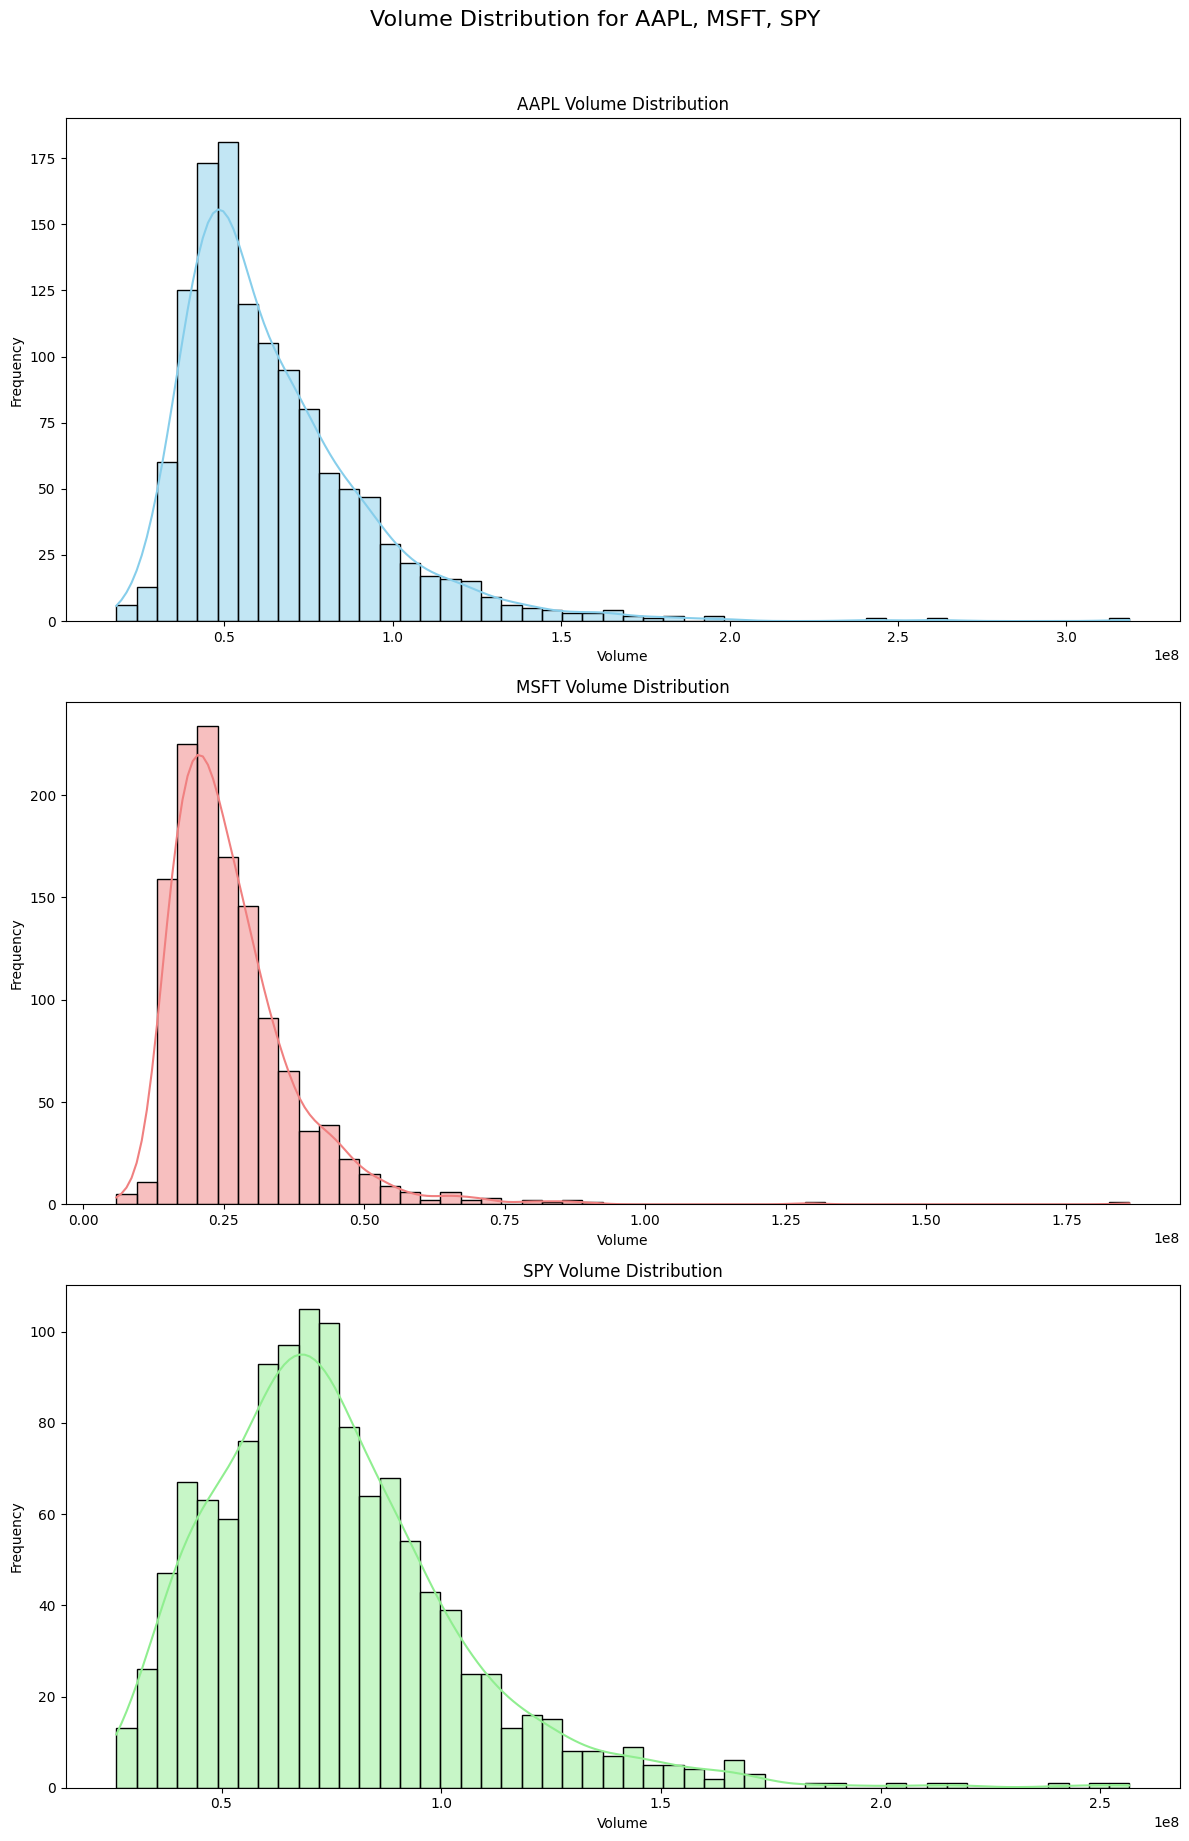

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for each stock
aapl_df = df[df['Stock_name'] == 'AAPL']
msft_df = df[df['Stock_name'] == 'MSFT']
spy_df = df[df['Stock_name'] == 'SPY']

# Create subplots for volume distribution
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
fig.suptitle('Volume Distribution for AAPL, MSFT, SPY', fontsize=16, y=1.02)

sns.histplot(aapl_df['Volume'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('AAPL Volume Distribution')
axes[0].set_xlabel('Volume')
axes[0].set_ylabel('Frequency')

sns.histplot(msft_df['Volume'], bins=50, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('MSFT Volume Distribution')
axes[1].set_xlabel('Volume')
axes[1].set_ylabel('Frequency')

sns.histplot(spy_df['Volume'], bins=50, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('SPY Volume Distribution')
axes[2].set_xlabel('Volume')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1319/2487034112.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stock_name', y='Volume', data=df[df['Stock_name'].isin(['AAPL', 'MSFT', 'SPY'])], palette='viridis')


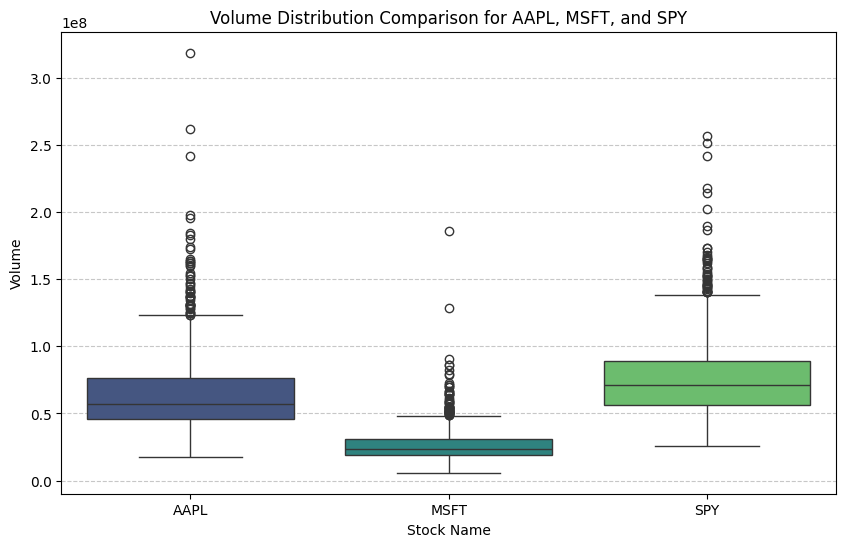

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Stock_name', y='Volume', data=df[df['Stock_name'].isin(['AAPL', 'MSFT', 'SPY'])], palette='viridis')
plt.title('Volume Distribution Comparison for AAPL, MSFT, and SPY')
plt.xlabel('Stock Name')
plt.ylabel('Volume')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [38]:
import plotly.graph_objects as go

# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Get unique stock names
stock_names = df['Stock_name'].unique()

### Interactive Candlestick Charts

In [37]:
import pandas as pd
import plotly.graph_objects as go

# Load CSV file
df = pd.read_csv('/content/Cleaned spreadsheet_new.csv')

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Get unique stock names
Stock_name = df['Stock_name'].unique()

# Create candlestick chart for each stock
for stock in Stock_name:

    # Filter data for the selected stock
    stock_df = df[df['Stock_name'] == stock].copy()

    # Sort by Date
    stock_df = stock_df.sort_values('Date')

    # Create candlestick chart
    fig = go.Figure(data=[
        go.Candlestick(
            x=stock_df['Date'],
            open=stock_df['Open'],
            high=stock_df['High'],
            low=stock_df['Low'],
            close=stock_df['Close']
        )
    ])

    # Customize chart
    fig.update_layout(
        title=f'{stock} Candlestick Chart',
        xaxis_title='Date',
        yaxis_title='Price',
        xaxis_rangeslider_visible=True
    )

    # Show chart
    fig.show()

### Simple Moving Averages (SMA) and Exponential Moving Averages (EMA)

Moving averages are widely used in technical analysis to smooth out price data over a specific period. They help in identifying trends and potential reversals.

*   **Simple Moving Average (SMA):** The average of a security's price over a set number of periods. It gives equal weight to all data points.
*   **Exponential Moving Average (EMA):** Similar to SMA, but it gives more weight to recent prices, making it more responsive to new information.

**Moving Average Crossovers:** Crossovers occur when a shorter-term moving average crosses a longer-term moving average. For example, a 50-day moving average crossing above a 200-day moving average is often considered a bullish signal (a "golden cross"), while crossing below can be a bearish signal (a "death cross").

In [43]:
# Calculate 50-day and 200-day SMA and EMA for each stock
for stock in Stock_name:
    stock_df = df[df['Stock_name'] == stock].copy()
    stock_df = stock_df.sort_values('Date')

    # Calculate SMA
    stock_df['SMA_50'] = stock_df['Close'].rolling(window=50).mean()
    stock_df['SMA_200'] = stock_df['Close'].rolling(window=200).mean()

    # Calculate EMA
    stock_df['EMA_50'] = stock_df['Close'].ewm(span=50, adjust=False).mean()
    stock_df['EMA_200'] = stock_df['Close'].ewm(span=200, adjust=False).mean()

    # Identify Golden Cross (50-day MA crosses above 200-day MA)
    stock_df['Golden_Cross_SMA'] = ((stock_df['SMA_50'].shift(1) < stock_df['SMA_200'].shift(1)) & (stock_df['SMA_50'] > stock_df['SMA_200']))
    stock_df['Golden_Cross_EMA'] = ((stock_df['EMA_50'].shift(1) < stock_df['EMA_200'].shift(1)) & (stock_df['EMA_50'] > stock_df['EMA_200']))

    # Identify Death Cross (50-day MA crosses below 200-day MA)
    stock_df['Death_Cross_SMA'] = ((stock_df['SMA_50'].shift(1) > stock_df['SMA_200'].shift(1)) & (stock_df['SMA_50'] < stock_df['SMA_200']))
    stock_df['Death_Cross_EMA'] = ((stock_df['EMA_50'].shift(1) > stock_df['EMA_200'].shift(1)) & (stock_df['EMA_50'] < stock_df['EMA_200']))

    # Plotting
    fig = go.Figure()

    fig.add_trace(go.Scatter(x=stock_df['Date'], y=stock_df['Close'], mode='lines', name='Close Price', line=dict(color='blue')))
    fig.add_trace(go.Scatter(x=stock_df['Date'], y=stock_df['SMA_50'], mode='lines', name='SMA 50', line=dict(color='red')))
    fig.add_trace(go.Scatter(x=stock_df['Date'], y=stock_df['SMA_200'], mode='lines', name='SMA 200', line=dict(color='green')))
    fig.add_trace(go.Scatter(x=stock_df['Date'], y=stock_df['EMA_50'], mode='lines', name='EMA 50', line=dict(color='purple', dash='dot')))
    fig.add_trace(go.Scatter(x=stock_df['Date'], y=stock_df['EMA_200'], mode='lines', name='EMA 200', line=dict(color='orange', dash='dash')))

    # Add Golden Cross markers (SMA)
    fig.add_trace(go.Scatter(x=stock_df[stock_df['Golden_Cross_SMA']]['Date'],
                             y=stock_df[stock_df['Golden_Cross_SMA']]['SMA_50'],
                             mode='markers',
                             marker=dict(symbol='triangle-up', size=10, color='gold'),
                             name='Golden Cross (SMA)',
                             hoverinfo='text',
                             hovertext=stock_df[stock_df['Golden_Cross_SMA']]['Date'].dt.strftime('%Y-%m-%d') + ' SMA Golden Cross'))

    # Add Death Cross markers (SMA)
    fig.add_trace(go.Scatter(x=stock_df[stock_df['Death_Cross_SMA']]['Date'],
                             y=stock_df[stock_df['Death_Cross_SMA']]['SMA_50'],
                             mode='markers',
                             marker=dict(symbol='triangle-down', size=10, color='black'),
                             name='Death Cross (SMA)',
                             hoverinfo='text',
                             hovertext=stock_df[stock_df['Death_Cross_SMA']]['Date'].dt.strftime('%Y-%m-%d') + ' SMA Death Cross'))

    # Add Golden Cross markers (EMA)
    fig.add_trace(go.Scatter(x=stock_df[stock_df['Golden_Cross_EMA']]['Date'],
                             y=stock_df[stock_df['Golden_Cross_EMA']]['EMA_50'],
                             mode='markers',
                             marker=dict(symbol='triangle-up', size=10, color='yellow'),
                             name='Golden Cross (EMA)',
                             hoverinfo='text',
                             hovertext=stock_df[stock_df['Golden_Cross_EMA']]['Date'].dt.strftime('%Y-%m-%d') + ' EMA Golden Cross'))

    # Add Death Cross markers (EMA)
    fig.add_trace(go.Scatter(x=stock_df[stock_df['Death_Cross_EMA']]['Date'],
                             y=stock_df[stock_df['Death_Cross_EMA']]['EMA_50'],
                             mode='markers',
                             marker=dict(symbol='triangle-down', size=10, color='gray'),
                             name='Death Cross (EMA)',
                             hoverinfo='text',
                             hovertext=stock_df[stock_df['Death_Cross_EMA']]['Date'].dt.strftime('%Y-%m-%d') + ' EMA Death Cross'))

    fig.update_layout(
        title=f'{stock} Close Price with 50-day & 200-day SMAs/EMAs and Crossovers',
        xaxis_title='Date',
        yaxis_title='Price',
        xaxis_rangeslider_visible=True
    )

    fig.show()

### Bollinger Bands for Volatility Clustering

**Bollinger Bands** are a type of statistical chart characterizing the prices and volatility of a financial instrument over time. They consist of a middle band, an upper band, and a lower band.

*   **Middle Band:** Typically a 20-period Simple Moving Average (SMA) of the closing price.
*   **Upper Band:** Set by taking the Middle Band and adding two standard deviations of the closing price to it.
*   **Lower Band:** Set by taking the Middle Band and subtracting two standard deviations of the closing price from it.

**Volatility Clustering:** This phenomenon occurs when periods of high volatility tend to be followed by periods of high volatility, and periods of low volatility tend to be followed by periods of low volatility. Bollinger Bands visually represent this by widening during high volatility and contracting during low volatility, providing insights into potential price breakouts or consolidations.

In [44]:
from plotly.subplots import make_subplots

WINDOW = 20

# Calculate Bollinger Bands and Volatility metrics for each stock and plot them
for stock in Stock_name:
    stock_df = df[df['Stock_name'] == stock].copy()
    stock_df = stock_df.sort_values('Date')

    # Calculate Middle Band (20-day SMA)
    stock_df['MA20'] = stock_df['Close'].rolling(WINDOW).mean()

    # Calculate Standard Deviation (20-day)
    stock_df['STD20'] = stock_df['Close'].rolling(WINDOW).std()

    # Calculate Upper and Lower Bollinger Bands
    stock_df['Upper'] = stock_df['MA20'] + (stock_df['STD20'] * 2)
    stock_df['Lower'] = stock_df['MA20'] - (stock_df['STD20'] * 2)

    # Calculate BandWidth
    stock_df['BandWidth'] = (stock_df['Upper'] - stock_df['Lower']) / stock_df['MA20']

    # Calculate daily returns and Rolling Volatility
    stock_df['Return'] = stock_df['Close'].pct_change()
    stock_df['RollVol20'] = stock_df['Return'].rolling(WINDOW).std() * np.sqrt(252)

    # Plotting with subplots
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.65, 0.35],
                         vertical_spacing=0.06,
                         subplot_titles=(f'{stock} Price with Bollinger Bands (20, 2σ)',
                                           'Band Width and Rolling Volatility — Volatility Clustering'))

    # Add Upper Band, Lower Band, Close Price, and MA20 to the first subplot
    fig.add_trace(go.Scatter(x=stock_df['Date'], y=stock_df['Upper'], line=dict(width=0.7, color='grey'), name='Upper Band'), row=1, col=1)
    fig.add_trace(go.Scatter(x=stock_df['Date'], y=stock_df['Lower'], line=dict(width=0.7, color='grey'), name='Lower Band',
                              fill='tonexty', fillcolor='rgba(180,180,180,0.2)'), row=1, col=1)
    fig.add_trace(go.Scatter(x=stock_df['Date'], y=stock_df['Close'], line=dict(color='royalblue'), name='Close'), row=1, col=1)
    fig.add_trace(go.Scatter(x=stock_df['Date'], y=stock_df['MA20'], line=dict(color='orange', dash='dot'), name='MA20'), row=1, col=1)

    # Add BandWidth and RollVol20 to the second subplot
    fig.add_trace(go.Scatter(x=stock_df['Date'], y=stock_df['BandWidth'], line=dict(color='crimson'), name='Band Width'), row=2, col=1)
    fig.add_trace(go.Scatter(x=stock_df['Date'], y=stock_df['RollVol20'], line=dict(color='darkgreen', dash='dash'), name='Rolling Volatility (Annualized)'), row=2, col=1)

    fig.update_layout(template='plotly_white', height=750, title=f'{stock} — Bollinger Bands & Volatility Clustering',
                      hovermode='x unified')

    fig.show()

# **Monthly Seasonality and Day-of-Week Returns**

Analyzing **monthly seasonality** and **day-of-week returns** can reveal patterns in stock prices that might be related to calendar effects. For instance, some months or specific days of the week may historically show higher or lower average returns due to various market behaviors or investor sentiment. This analysis helps identify if there are any consistent trends over different periods.

# **Stock market seasonality analysis by calculating the average daily return for each stock in each month.**

Creates a copy of the dataset.
Converts Date into datetime format.
Extracts Month and Day of Week from the date.
Calculates daily percentage returns for each stock.
Removes missing return values.
Calculates the average monthly return for each stock.
Arranges the months in chronological order from January to December.

Purpose: To identify which months historically have better or worse stock performance for AAPL, MSFT, and SPY.

In [54]:
# Prepare data for seasonality analysis
seasonal_df = df.copy()
seasonal_df['Date'] = pd.to_datetime(seasonal_df['Date'])
seasonal_df['Month'] = seasonal_df['Date'].dt.month_name()
seasonal_df['Day_of_Week'] = seasonal_df['Date'].dt.day_name()

# Calculate daily returns for each stock
seasonal_df['Daily_Return'] = seasonal_df.groupby('Stock_name')['Close'].pct_change() * 100

# Drop NaN values introduced by pct_change
seasonal_df = seasonal_df.dropna(subset=['Daily_Return'])

# Calculate average monthly returns
monthly_returns = seasonal_df.groupby(['Stock_name', 'Month'])['Daily_Return'].mean().reset_index()

# Define the order of months for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_returns['Month'] = pd.Categorical(monthly_returns['Month'], categories=month_order, ordered=True)
monthly_returns = monthly_returns.sort_values('Month')

# **Creates an interactive bar chart showing the average monthly stock returns for each stock.**

import plotly.express as px → Imports Plotly for visualization.
for stock in Stock_name: → Loops through each stock (AAPL, MSFT, SPY).
stock_monthly_returns = ... → Filters monthly return data for the current stock.
px.bar(...) → Creates a bar chart with:
X-axis: Month
Y-axis: Average Daily Return (%)
Color: Return value, using a red-blue color scale.
fig.update_layout(...) → Sets the axis titles.
fig.show() → Displays the interactive chart.

Purpose: To visually compare the average daily returns of each stock across different months and identify positive or negative seasonal patterns.

In [55]:
import plotly.express as px

# Plot average monthly returns
for stock in Stock_name:
    stock_monthly_returns = monthly_returns[monthly_returns['Stock_name'] == stock]
    fig = px.bar(stock_monthly_returns, x='Month', y='Daily_Return',
                 title=f'{stock} Average Monthly Returns',
                 labels={'Daily_Return': 'Average Daily Return (%)'},
                 color='Daily_Return', color_continuous_scale=px.colors.sequential.RdBu)
    fig.update_layout(xaxis_title='Month', yaxis_title='Average Daily Return (%)')
    fig.show()

# **Calculates the average daily stock return for each day of the week.**

groupby(['Stock_name', 'Day_of_Week']) → Groups the data by stock and day of the week.
.mean() → Calculates the average Daily_Return for each group.
reset_index() → Converts the grouped result back into a normal DataFrame.
day_order → Defines the correct order: Monday → Friday.
pd.Categorical(...) → Ensures the days are treated in this order instead of alphabetical order.
sort_values('Day_of_Week') → Sorts the results from Monday to Friday.

Purpose: To identify whether stocks like AAPL, MSFT, and SPY tend to have better or worse average returns on particular weekdays.

In [56]:
# Calculate average day-of-week returns
dayofweek_returns = seasonal_df.groupby(['Stock_name', 'Day_of_Week'])['Daily_Return'].mean().reset_index()

# Define the order of days for plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
dayofweek_returns['Day_of_Week'] = pd.Categorical(dayofweek_returns['Day_of_Week'], categories=day_order, ordered=True)
dayofweek_returns = dayofweek_returns.sort_values('Day_of_Week')

# **Creates an interactive bar chart showing the average stock return for each day of the week.**

for stock in Stock_name: → Loops through each stock, such as AAPL, MSFT, and SPY.
stock_dayofweek_returns = ... → Filters the data for the current stock.
px.bar(...) → Creates a bar chart.
X-axis: Day of the week (Monday–Friday)
Y-axis: Average daily return (%)
Color: Represents the return value using a red-blue color scale.
fig.update_layout(...) → Sets the X-axis and Y-axis labels.
fig.show() → Displays the interactive chart.

Purpose: To compare the average performance of each stock across different weekdays and identify if a stock tends to perform better or worse on a particular day.

In [60]:
# Plot average day-of-week returns
for stock in Stock_name:
    stock_dayofweek_returns = dayofweek_returns[dayofweek_returns['Stock_name'] == stock]
    fig = px.bar(stock_dayofweek_returns, x='Day_of_Week', y='Daily_Return',
                 title=f'{stock} Average Day-of-Week Returns',
                 labels={'Daily_Return': 'Average Daily Return (%)'},
                 color='Daily_Return', color_continuous_scale=px.colors.sequential.RdBu)
    fig.update_layout(xaxis_title='Day of Week', yaxis_title='Average Daily Return (%)')
    fig.show()

# **Overall Average Monthly and Day-of-Week Returns (Across all Stocks)**

Overall Average Monthly and Day-of-Week Returns (Across all Stocks) means calculating the average stock return across AAPL, MSFT, and SPY together.

Average Monthly Returns → Finds the average daily return for each month by combining data from all stocks.
Average Day-of-Week Returns → Finds the average daily return for each weekday (Monday–Friday) across all stocks.
This helps identify overall market seasonality, such as which months or weekdays generally show better or worse stock performance.

Purpose: To understand the common seasonal patterns and overall return trends across the entire group of stocks, rather than analyzing each stock separately.

In [61]:
# Calculate overall average monthly returns across all stocks
overall_monthly_returns = seasonal_df.groupby('Month')['Daily_Return'].mean().reset_index()
overall_monthly_returns['Month'] = pd.Categorical(overall_monthly_returns['Month'], categories=month_order, ordered=True)
overall_monthly_returns = overall_monthly_returns.sort_values('Month')
overall_monthly_returns = overall_monthly_returns.set_index('Month')
overall_monthly_returns.columns = ['Return']

print('Monthly average return (%):')
print(overall_monthly_returns.round(3))

Monthly average return (%):
           Return
Month            
January    -0.026
February   -0.048
March       0.027
April       0.007
May         0.240
June        0.019
July        0.237
August      0.016
September  -0.154
October     0.162
November    0.220
December   -0.025


In [63]:
# Calculate overall average day-of-week returns across all stocks
overall_dayofweek_returns = seasonal_df.groupby('Day_of_Week')['Daily_Return'].mean().reset_index()
overall_dayofweek_returns['Day_of_Week'] = pd.Categorical(overall_dayofweek_returns['Day_of_Week'], categories=day_order, ordered=True)
overall_dayofweek_returns = overall_dayofweek_returns.sort_values('Day_of_Week')
overall_dayofweek_returns = overall_dayofweek_returns.set_index('Day_of_Week')
overall_dayofweek_returns.columns = ['Return']

print('\nDay-of-week average return (%):')
print(overall_dayofweek_returns.round(3))


Day-of-week average return (%):
             Return
Day_of_Week        
Monday        0.090
Tuesday       0.031
Wednesday     0.153
Thursday     -0.040
Friday        0.054
